# Import the Google Colab drive module to handle data storage and retrieval and mount the drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Environment Setup
Install essential libraries for text embedding (`sentence-transformers`), fairness analysis (`fairlearn`), machine learning (`scikit-learn`), and data visualization (`seaborn`).

In [2]:
!pip -q install sentence-transformers fairlearn scikit-learn seaborn joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 22.7 MB/s eta 0:00:00


### Imports and Configuration
This cell imports core libraries for .

1. Data Processing (`pandas`, `numpy`)
2. Visualization (`seaborn`, `matplotlib`)
3. Machine Learning (`scikit-learn`)
4. fairness auditing (`fairlearn`)

It also initializes the `sentence-transformers` library for text embedding.



In [3]:
import os
import re
import random
import warnings
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

from fairlearn.metrics import MetricFrame, demographic_parity_difference, selection_rate

warnings.filterwarnings("ignore")

# Set global random seed to ensure reproducibility across random and numpy operations


In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

### Directory Setup
Create a organized folder structure in Google Drive to store the raw dataset, trained machine learning models, and resulting analysis files (CSV results and visualization plots).

In [5]:
BASE_DIR = "/content/drive/MyDrive/MSc IT/3rd sem/model"
DATA_DIR = os.path.join(BASE_DIR, "data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")

for folder in [BASE_DIR, DATA_DIR, MODEL_DIR, RESULTS_DIR, PLOTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


# Load the resume dataset from Google Drive and display its dimensions and initial rows


In [6]:
DATA_PATH = os.path.join(DATA_DIR, "resume_dataset.csv")
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1730, 11)


,job_id,resume_id,job_text,resume_text,skills_text,education_text,experience_text,certifications_text,gender,race,label_relevant
0,JOB004,R0001,Job Title: DevOps Engineer Company: CloudBase ...,Barbara Garcia Email: r0001@email.com SKILLS S...,"SQL, Jenkins, Ansible, Docker","BSc Statistics, University of Leeds (2017)",Machine Learning Engineer at CloudBase Ltd (20...,Google Professional Data Engineer,Female,White,0
1,JOB004,R0002,Job Title: DevOps Engineer Company: CloudBase ...,James Rodriguez Email: r0002@email.com SKILLS ...,"CI/CD, Kubernetes, Jenkins, Docker, Big Data, ...","MSc Computer Science, London Metropolitan Univ...",Backend Developer at TechCorp Ltd (2021-2022):...,"Tableau Desktop Specialist, Databricks Certifi...",Male,White,1
2,JOB004,R0003,Job Title: DevOps Engineer Company: CloudBase ...,Kwame Traoré Email: r0003@email.com SKILLS PyT...,"PyTorch, Deep Learning, Bash, R, AWS, NLP, Fas...","MSc Computer Science, University of Manchester...",Backend Developer at CloudBase Ltd (2018-2021)...,Microsoft Azure Fundamentals,Male,Black,0
3,JOB005,R0004,Job Title: Data Engineer Company: PrismData Lt...,Liam Martinez Email: r0004@email.com SKILLS SQ...,"SQL, Kubernetes, PostgreSQL, Jenkins, Redis, N...","BA Business Information Systems, City Universi...",Data Analyst at BetaWorks (2019-2022): Applied...,"Certified Ethical Hacker, AWS Machine Learning...",Male,White,1
4,JOB001,R0005,Job Title: Data Scientist Company: TechCorp Lt...,Fatima Taylor Email: r0005@email.com SKILLS Da...,"Data Visualisation, CI/CD, Computer Vision, Sc...","MSc Computer Science, University of Hertfordsh...",Backend Developer at Acme Digital (2022-2025):...,"Agile Scrum Master, Certified Ethical Hacker",Female,White,0


#Perform EDA

In [7]:
print(df.columns.tolist())
print("\nMissing values:\n")
print(df.isnull().sum())

['job_id', 'resume_id', 'job_text', 'resume_text', 'skills_text', 'education_text', 'experience_text', 'certifications_text', 'gender', 'race', 'label_relevant']

Missing values:

job_id                   0
resume_id                0
job_text                 0
resume_text              0
skills_text              0
education_text           0
experience_text          0
certifications_text    402
gender                   0
race                     0
label_relevant           0
dtype: int64


In [8]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [9]:
text_columns = [
    "job_text",
    "resume_text",
    "skills_text",
    "education_text",
    "experience_text",
    "certifications_text"
]

for col in text_columns:
    df[col] = df[col].apply(clean_text)

df.head()

,job_id,resume_id,job_text,resume_text,skills_text,education_text,experience_text,certifications_text,gender,race,label_relevant
0,JOB004,R0001,job title: devops engineer company: cloudbase ...,barbara garcia email: r0001@email.com skills s...,"sql, jenkins, ansible, docker","bsc statistics, university of leeds (2017)",machine learning engineer at cloudbase ltd (20...,google professional data engineer,Female,White,0
1,JOB004,R0002,job title: devops engineer company: cloudbase ...,james rodriguez email: r0002@email.com skills ...,"ci/cd, kubernetes, jenkins, docker, big data, ...","msc computer science, london metropolitan univ...",backend developer at techcorp ltd (2021-2022):...,"tableau desktop specialist, databricks certifi...",Male,White,1
2,JOB004,R0003,job title: devops engineer company: cloudbase ...,kwame traoré email: r0003@email.com skills pyt...,"pytorch, deep learning, bash, r, aws, nlp, fas...","msc computer science, university of manchester...",backend developer at cloudbase ltd (2018-2021)...,microsoft azure fundamentals,Male,Black,0
3,JOB005,R0004,job title: data engineer company: prismdata lt...,liam martinez email: r0004@email.com skills sq...,"sql, kubernetes, postgresql, jenkins, redis, n...","ba business information systems, city universi...",data analyst at betaworks (2019-2022): applied...,"certified ethical hacker, aws machine learning...",Male,White,1
4,JOB001,R0005,job title: data scientist company: techcorp lt...,fatima taylor email: r0005@email.com skills da...,"data visualisation, ci/cd, computer vision, sc...","msc computer science, university of hertfordsh...",backend developer at acme digital (2022-2025):...,"agile scrum master, certified ethical hacker",Female,White,0


In [10]:
print("Number of unique jobs:", df["job_id"].nunique())
print("Number of unique resumes:", df["resume_id"].nunique())

print("\nGender distribution:")
print(df["gender"].value_counts(dropna=False))

print("\nRace distribution:")
print(df["race"].value_counts(dropna=False))

print("\nLabel distribution:")
print(df["label_relevant"].value_counts(dropna=False))

Number of unique jobs: 5
Number of unique resumes: 1730

Gender distribution:
gender
Female        849
Male          805
Non-binary     76
Name: count, dtype: int64

Race distribution:
race
White       1397
Asian        127
Black         77
Hispanic      74
Other         55
Name: count, dtype: int64

Label distribution:
label_relevant
1    1050
0     680
Name: count, dtype: int64


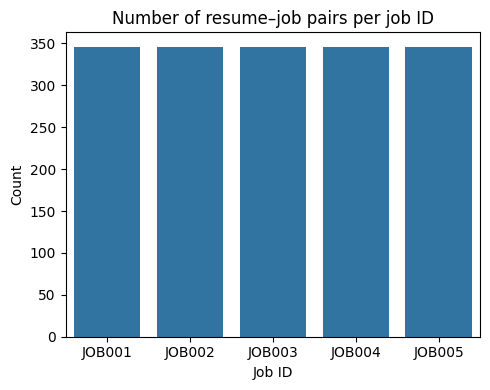

In [11]:
plt.figure(figsize=(5, 4))
job_counts = df["job_id"].value_counts().sort_index()
sns.barplot(x=job_counts.index, y=job_counts.values, color="#1f77b4")
plt.title("Number of resume–job pairs per job ID")
plt.xlabel("Job ID")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "jobid_counts.png"))
plt.show()

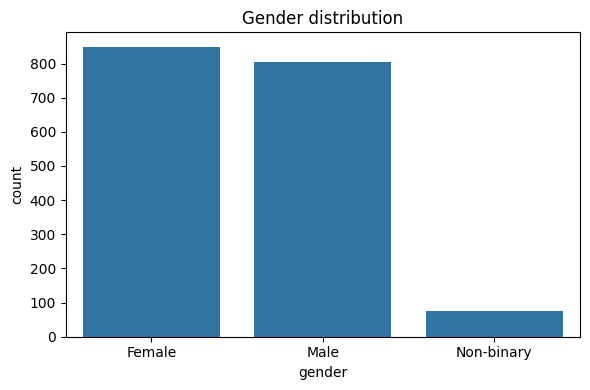

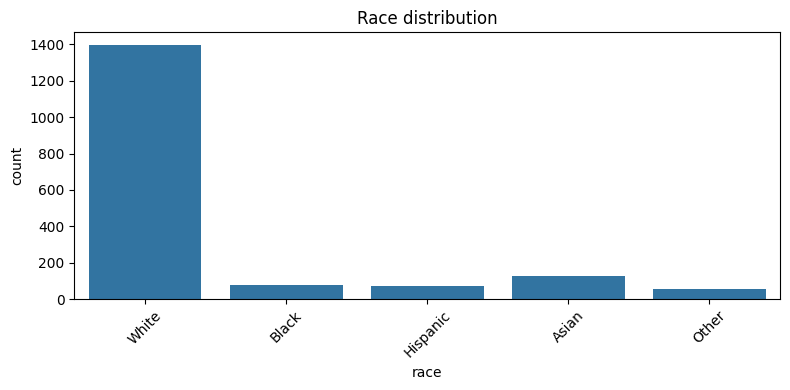

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="gender")
plt.title("Gender distribution")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "gender_distribution.png"))
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(data=df, x="race")
plt.title("Race distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "race_distribution.png"))
plt.show()

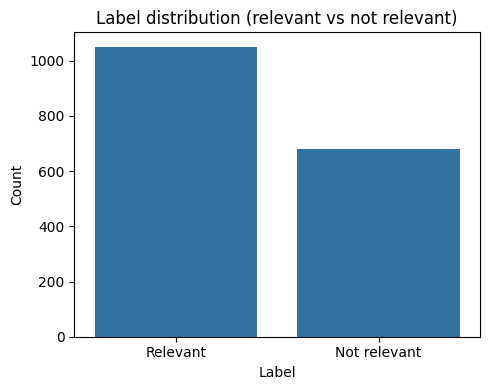

In [13]:
plt.figure(figsize=(5, 4))
label_names = {0: "Not relevant", 1: "Relevant"}
sns.countplot(
    data=df,
    x="label_relevant",
    order=[1, 0]
)
plt.title("Label distribution (relevant vs not relevant)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0, 1], [label_names[1], label_names[0]])
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "label_distribution.png"))
plt.show()

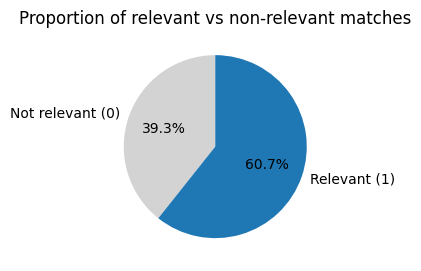

In [14]:
plt.figure(figsize=(4, 4))
label_counts = df["label_relevant"].value_counts().sort_index()
labels = ["Not relevant (0)", "Relevant (1)"]
plt.pie(
    label_counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#d3d3d3", "#1f77b4"]
)
plt.title("Proportion of relevant vs non‑relevant matches")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "label_proportion_pie.png"))
plt.show()

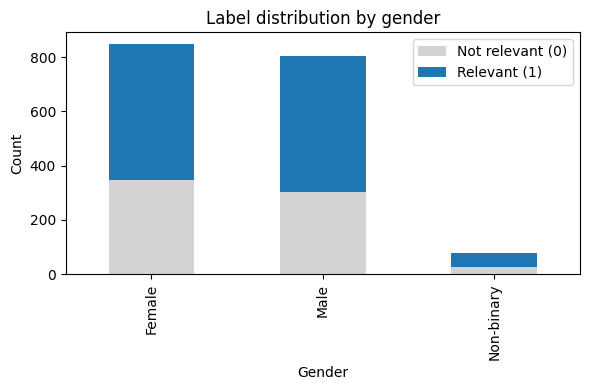

In [15]:
ct_gender = pd.crosstab(df["gender"], df["label_relevant"])

ct_gender.plot(
    kind="bar",
    stacked=True,
    figsize=(6, 4),
    color=["#d3d3d3", "#1f77b4"]
)
plt.title("Label distribution by gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(["Not relevant (0)", "Relevant (1)"])
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "label_by_gender_stacked.png"))
plt.show()

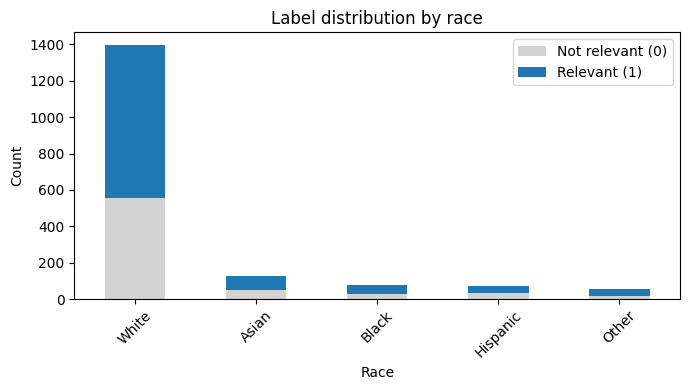

In [16]:
ct_race = pd.crosstab(df["race"], df["label_relevant"])
race_order = ["White", "Asian", "Black", "Hispanic", "Other"]
ct_race = ct_race.loc[race_order]

ct_race.plot(
    kind="bar",
    stacked=True,          # switch to False for grouped bars
    figsize=(7, 4),
    color=["#d3d3d3", "#1f77b4"]
)
plt.title("Label distribution by race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.legend(["Not relevant (0)", "Relevant (1)"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "label_by_race_stacked.png"))
plt.show()

In [17]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label_relevant"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_df["label_relevant"]
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1384, 11)
Validation shape: (173, 11)
Test shape: (173, 11)


In [18]:
embedding_model_name = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(embedding_model_name)

print("Loaded model:", embedding_model_name)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded model: sentence-transformers/all-MiniLM-L6-v2


In [19]:
def encode_texts(texts, model, batch_size=32):
    return model.encode(
        texts.tolist(),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True
    )

In [20]:
train_job_emb = encode_texts(train_df["job_text"], embedder)
train_resume_emb = encode_texts(train_df["resume_text"], embedder)
train_skills_emb = encode_texts(train_df["skills_text"], embedder)
train_edu_emb = encode_texts(train_df["education_text"], embedder)
train_exp_emb = encode_texts(train_df["experience_text"], embedder)
train_cert_emb = encode_texts(train_df["certifications_text"], embedder)

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

In [21]:
val_job_emb = encode_texts(val_df["job_text"], embedder)
val_resume_emb = encode_texts(val_df["resume_text"], embedder)
val_skills_emb = encode_texts(val_df["skills_text"], embedder)
val_edu_emb = encode_texts(val_df["education_text"], embedder)
val_exp_emb = encode_texts(val_df["experience_text"], embedder)
val_cert_emb = encode_texts(val_df["certifications_text"], embedder)

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

In [22]:
test_job_emb = encode_texts(test_df["job_text"], embedder)
test_resume_emb = encode_texts(test_df["resume_text"], embedder)
test_skills_emb = encode_texts(test_df["skills_text"], embedder)
test_edu_emb = encode_texts(test_df["education_text"], embedder)
test_exp_emb = encode_texts(test_df["experience_text"], embedder)
test_cert_emb = encode_texts(test_df["certifications_text"], embedder)

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

In [23]:
def rowwise_cosine(a, b):
    sims = []
    for i in range(len(a)):
        sim = cosine_similarity(a[i].reshape(1, -1), b[i].reshape(1, -1))[0][0]
        sims.append(sim)
    return np.array(sims)

In [24]:
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

for split_df, job_emb, resume_emb, skills_emb, edu_emb, exp_emb, cert_emb in [
    (train_df, train_job_emb, train_resume_emb, train_skills_emb, train_edu_emb, train_exp_emb, train_cert_emb),
    (val_df, val_job_emb, val_resume_emb, val_skills_emb, val_edu_emb, val_exp_emb, val_cert_emb),
    (test_df, test_job_emb, test_resume_emb, test_skills_emb, test_edu_emb, test_exp_emb, test_cert_emb),
]:
    split_df["full_similarity"] = rowwise_cosine(job_emb, resume_emb)
    split_df["skills_similarity"] = rowwise_cosine(job_emb, skills_emb)
    split_df["education_similarity"] = rowwise_cosine(job_emb, edu_emb)
    split_df["experience_similarity"] = rowwise_cosine(job_emb, exp_emb)
    split_df["certifications_similarity"] = rowwise_cosine(job_emb, cert_emb)

train_df.head()

,job_id,resume_id,job_text,resume_text,skills_text,education_text,experience_text,certifications_text,gender,race,label_relevant,full_similarity,skills_similarity,education_similarity,experience_similarity,certifications_similarity
1445,JOB005,R1446,job title: data engineer company: prismdata lt...,priya rodriguez email: r1446@email.com skills ...,"pytorch, power bi, airflow, github actions, py...","msc computer science, university of birmingham...",junior developer at nexgen analytics (2016-201...,"microsoft azure fundamentals, comptia security...",Female,White,1,0.637086,0.396988,0.284419,0.380810,0.437518
917,JOB001,R0918,job title: data scientist company: techcorp lt...,"ava lopez email: r0918@email.com skills java, ...","java, nlp, data visualisation, pandas, tensorf...","bsc computer science, university of warwick (2...",data engineer at datasolutions uk (2020-2021):...,,Female,White,1,0.730256,0.512166,0.424586,0.663339,0.074907
646,JOB003,R0647,job title: machine learning engineer company: ...,maria thompson email: r0647@email.com skills t...,"tensorflow, kafka, spark, typescript, python, ...","bsc statistics, university of hertfordshire (2...",qa engineer at innovatesoft (2017-2018): appli...,,Female,White,1,0.529086,0.404629,0.245549,0.345495,0.106923
1405,JOB002,R1406,job title: software engineer company: innovate...,"john chen email: r1406@email.com skills ci/cd,...","ci/cd, python, sql, azure, react, rest apis, p...","msc computer science, london metropolitan univ...",devops engineer at datasolutions uk (2018-2019...,"aws machine learning specialty, pmp project ma...",Male,Asian,1,0.664413,0.441815,0.184735,0.396276,0.406035
1312,JOB002,R1313,job title: software engineer company: innovate...,susan gonzalez email: r1313@email.com skills j...,"javascript, scikit-learn, machine learning, re...","bsc statistics, university of manchester (2015)",data analyst at gamma digital (2015-2017): app...,"tableau desktop specialist, certified kubernet...",Female,White,0,0.557427,0.247379,0.225097,0.357690,0.517130


In [25]:
test_ranked = test_df.copy()
test_ranked["baseline_rank"] = test_ranked.groupby("job_id")["full_similarity"] \
    .rank(method="first", ascending=False)

test_ranked = test_ranked.sort_values(["job_id", "baseline_rank"])
test_ranked.head(20)

,job_id,resume_id,job_text,resume_text,skills_text,education_text,experience_text,certifications_text,gender,race,label_relevant,full_similarity,skills_similarity,education_similarity,experience_similarity,certifications_similarity,baseline_rank
282,JOB001,R0283,job title: data scientist company: techcorp lt...,jennifer smith email: r0283@email.com skills m...,"machine learning, python, tensorflow, javascri...","bsc statistics, university of greenwich (2019)",devops engineer at innovatesoft (2019-2022): a...,google professional data engineer,Female,Hispanic,1,0.767553,0.535157,0.305445,0.583739,0.585326,1.0
861,JOB001,R0862,job title: data scientist company: techcorp lt...,noah patel email: r0862@email.com skills sciki...,"scikit-learn, terraform, python, data visualis...","bsc cybersecurity, de montfort university (2023)",data analyst at globaltech systems (2018-2021)...,"google professional data engineer, tableau des...",Male,White,1,0.761458,0.554724,0.411633,0.682165,0.547165,2.0
324,JOB001,R0325,job title: data scientist company: techcorp lt...,elijah osei email: r0325@email.com skills type...,"typescript, tensorflow, python, statistics, sq...","bsc software engineering, university of edinbu...",data analyst at techcorp ltd (2021-2023): appl...,"aws solutions architect, agile scrum master",Male,Other,1,0.749842,0.510990,0.415715,0.722952,0.303672,3.0
165,JOB001,R0166,job title: data scientist company: techcorp lt...,robert adeyemi email: r0166@email.com skills t...,"tensorflow, terraform, scikit-learn, statistic...","bsc software engineering, de montfort universi...",qa engineer at techcorp ltd (2015-2018): appli...,"tableau desktop specialist, certified kubernet...",Male,White,1,0.742984,0.577360,0.409890,0.633716,0.364784,4.0
1660,JOB001,R1661,job title: data scientist company: techcorp lt...,jordan kim email: r1661@email.com skills tenso...,"tensorflow, java, computer vision, a/b testing...","bsc cybersecurity, university of leeds (2012)",data analyst at cloudbase ltd (2021-2023): app...,"aws machine learning specialty, google cloud p...",Non-binary,White,1,0.738292,0.580433,0.375701,0.550816,0.612756,5.0
1495,JOB001,R1496,job title: data scientist company: techcorp lt...,lisa kim email: r1496@email.com skills machine...,"machine learning, docker, scikit-learn, java, ...","bsc cybersecurity, london metropolitan univers...",junior developer at datasolutions uk (2022-202...,"google professional data engineer, agile scrum...",Female,White,1,0.733346,0.503041,0.348067,0.605993,0.468799,6.0
207,JOB001,R0208,job title: data scientist company: techcorp lt...,"liam nguyen email: r0208@email.com skills r, s...","r, spark, python, tensorflow, statistics, syst...","bsc computer science, coventry university (2022)",qa engineer at datasolutions uk (2021-2023): a...,databricks certified associate,Male,White,1,0.729664,0.513127,0.440455,0.604645,0.500581,7.0
1715,JOB001,R1716,job title: data scientist company: techcorp lt...,"emma li email: r1716@email.com skills ansible,...","ansible, tensorflow, scikit-learn, statistics,...","bsc statistics, university of edinburgh (2017)",systems analyst at nexgen analytics (2015-2018...,"aws certified developer, tableau desktop speci...",Female,Asian,1,0.726217,0.529317,0.361664,0.529716,0.470848,8.0
170,JOB001,R0171,job title: data scientist company: techcorp lt...,aisha rodriguez email: r0171@email.com skills ...,"ci/cd, data visualisation, ansible, machine le...","bsc statistics, london metropolitan university...",devops engineer at alphatech (2018-2019): appl...,,Female,White,0,0.702509,0.529867,0.292008,0.564827,0.074907,9.0
180,JOB001,R0181,job title: data scientist company: techcorp lt...,isabella patel email: r0181@email.com skills t...,"tensorflow, sql, redshift, etl, data visualisa...","beng information technology, university of her...",data analyst at cloudbase ltd (2019-2020): app...,,Female,White,1,0.675754,0.577342,0.279685,0.636514,0.074907,10.0


In [26]:
baseline_path = os.path.join(RESULTS_DIR, "baseline_rankings.csv")
test_ranked.to_csv(baseline_path, index=False)
print("Saved baseline rankings to:", baseline_path)

Saved baseline rankings to: /content/drive/MyDrive/MSc IT/3rd sem/model/results/baseline_rankings.csv


In [27]:
print("Mean full similarity by gender:")
print(test_ranked.groupby("gender")["full_similarity"].mean())

print("\nMean full similarity by race:")
print(test_ranked.groupby("race")["full_similarity"].mean())

Mean full similarity by gender:
gender
Female        0.637105
Male          0.636596
Non-binary    0.636085
Name: full_similarity, dtype: float32

Mean full similarity by race:
race
Asian       0.605086
Black       0.655599
Hispanic    0.664650
Other       0.645317
White       0.638354
Name: full_similarity, dtype: float32


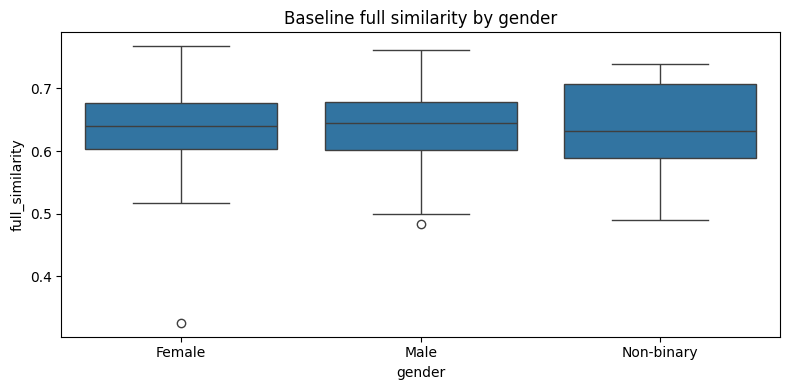

In [28]:
plt.figure(figsize=(8,4))
sns.boxplot(data=test_ranked, x="gender", y="full_similarity")
plt.title("Baseline full similarity by gender")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "baseline_similarity_by_gender.png"))
plt.show()

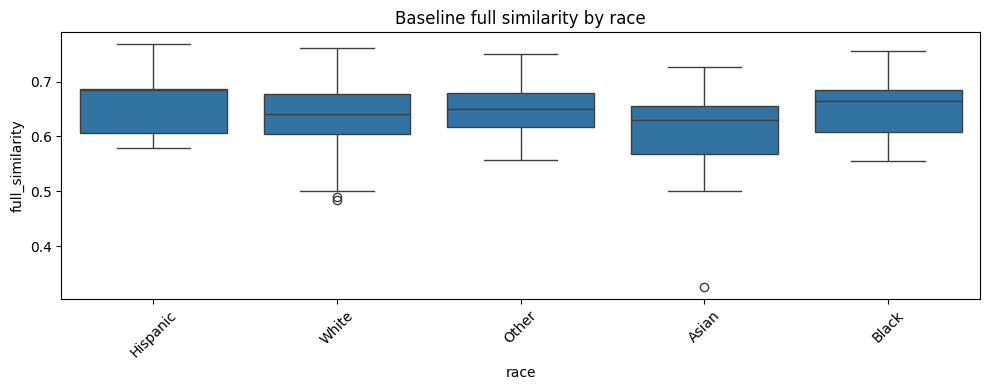

In [29]:
plt.figure(figsize=(10,4))
sns.boxplot(data=test_ranked, x="race", y="full_similarity")
plt.title("Baseline full similarity by race")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "baseline_similarity_by_race.png"))
plt.show()

In [30]:
TOP_K = 10

test_ranked["selected_top_k"] = (test_ranked["baseline_rank"] <= TOP_K).astype(int)
test_ranked[["job_id", "resume_id", "baseline_rank", "selected_top_k"]].head(20)

,job_id,resume_id,baseline_rank,selected_top_k
282,JOB001,R0283,1.0,1
861,JOB001,R0862,2.0,1
324,JOB001,R0325,3.0,1
165,JOB001,R0166,4.0,1
1660,JOB001,R1661,5.0,1
1495,JOB001,R1496,6.0,1
207,JOB001,R0208,7.0,1
1715,JOB001,R1716,8.0,1
170,JOB001,R0171,9.0,1
180,JOB001,R0181,10.0,1


In [31]:
print("Selection rate by gender:")
print(test_ranked.groupby("gender")["selected_top_k"].mean())

print("\nSelection rate by race:")
print(test_ranked.groupby("race")["selected_top_k"].mean())

Selection rate by gender:
gender
Female        0.289157
Male          0.277108
Non-binary    0.428571
Name: selected_top_k, dtype: float64

Selection rate by race:
race
Asian       0.157895
Black       0.400000
Hispanic    0.600000
Other       0.333333
White       0.284615
Name: selected_top_k, dtype: float64


In [32]:
dpd_gender = demographic_parity_difference(
    y_true=test_ranked["label_relevant"],
    y_pred=test_ranked["selected_top_k"],
    sensitive_features=test_ranked["gender"]
)

dpd_race = demographic_parity_difference(
    y_true=test_ranked["label_relevant"],
    y_pred=test_ranked["selected_top_k"],
    sensitive_features=test_ranked["race"]
)

print("Demographic parity difference (gender):", dpd_gender)
print("Demographic parity difference (race):", dpd_race)

Demographic parity difference (gender): 0.15146299483648878
Demographic parity difference (race): 0.4421052631578947


In [33]:
mf_gender = MetricFrame(
    metrics={"selection_rate": selection_rate},
    y_true=test_ranked["label_relevant"],
    y_pred=test_ranked["selected_top_k"],
    sensitive_features=test_ranked["gender"]
)

mf_race = MetricFrame(
    metrics={"selection_rate": selection_rate},
    y_true=test_ranked["label_relevant"],
    y_pred=test_ranked["selected_top_k"],
    sensitive_features=test_ranked["race"]
)

print("By gender:\n", mf_gender.by_group)
print("\nBy race:\n", mf_race.by_group)

By gender:
             selection_rate
gender                    
Female            0.289157
Male              0.277108
Non-binary        0.428571

By race:
           selection_rate
race                    
Asian           0.157895
Black           0.400000
Hispanic        0.600000
Other           0.333333
White           0.284615


In [34]:
section_cols = [
    "skills_similarity",
    "education_similarity",
    "experience_similarity",
    "certifications_similarity"
]

for col in section_cols:
    print(f"\nMean {col} by gender")
    print(test_ranked.groupby("gender")[col].mean())

for col in section_cols:
    print(f"\nMean {col} by race")
    print(test_ranked.groupby("race")[col].mean())


Mean skills_similarity by gender
gender
Female        0.447397
Male          0.441466
Non-binary    0.437485
Name: skills_similarity, dtype: float32

Mean education_similarity by gender
gender
Female        0.287078
Male          0.286199
Non-binary    0.309473
Name: education_similarity, dtype: float32

Mean experience_similarity by gender
gender
Female        0.488562
Male          0.508855
Non-binary    0.454533
Name: experience_similarity, dtype: float32

Mean certifications_similarity by gender
gender
Female        0.342631
Male          0.346056
Non-binary    0.395534
Name: certifications_similarity, dtype: float32

Mean skills_similarity by race
race
Asian       0.419758
Black       0.458020
Hispanic    0.448583
Other       0.452639
White       0.445890
Name: skills_similarity, dtype: float32

Mean education_similarity by race
race
Asian       0.286044
Black       0.276767
Hispanic    0.259224
Other       0.329084
White       0.286830
Name: education_similarity, dtype: float32


In [35]:
gender_encoder = LabelEncoder()

train_gender = gender_encoder.fit_transform(train_df["gender"])
test_gender = gender_encoder.transform(test_df["gender"])

gender_probe = LogisticRegression(max_iter=1000, random_state=SEED)
gender_probe.fit(train_resume_emb, train_gender)

gender_pred = gender_probe.predict(test_resume_emb)

print("Gender probe accuracy:", accuracy_score(test_gender, gender_pred))
print("Gender probe F1:", f1_score(test_gender, gender_pred, average="weighted"))
print("\nClassification report:\n")
print(classification_report(test_gender, gender_pred))

Gender probe accuracy: 0.9421965317919075
Gender probe F1: 0.922732476374618

Classification report:

              precision    recall  f1-score   support

           0       0.94      0.99      0.96        83
           1       0.94      0.98      0.96        83
           2       0.00      0.00      0.00         7

    accuracy                           0.94       173
   macro avg       0.63      0.65      0.64       173
weighted avg       0.90      0.94      0.92       173



In [36]:
race_encoder = LabelEncoder()

train_race = race_encoder.fit_transform(train_df["race"])
test_race = race_encoder.transform(test_df["race"])

race_probe = LogisticRegression(max_iter=1000, random_state=SEED)
race_probe.fit(train_resume_emb, train_race)

race_pred = race_probe.predict(test_resume_emb)

print("Race probe accuracy:", accuracy_score(test_race, race_pred))
print("Race probe F1:", f1_score(test_race, race_pred, average="weighted"))
print("\nClassification report:\n")
print(classification_report(test_race, race_pred))

Race probe accuracy: 0.7514450867052023
Race probe F1: 0.6448043648295465

Classification report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        19
           1       0.00      0.00      0.00        10
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         9
           4       0.75      1.00      0.86       130

    accuracy                           0.75       173
   macro avg       0.15      0.20      0.17       173
weighted avg       0.56      0.75      0.64       173



In [37]:
feature_cols = [
    "full_similarity",
    "skills_similarity",
    "education_similarity",
    "experience_similarity",
    "certifications_similarity"
]

X_train = train_df[feature_cols]
y_train = train_df["label_relevant"]

X_val = val_df[feature_cols]
y_val = val_df["label_relevant"]

X_test = test_df[feature_cols]
y_test = test_df["label_relevant"]

In [38]:
scorer_model = LogisticRegression(max_iter=1000, random_state=SEED)
scorer_model.fit(X_train, y_train)

val_pred = scorer_model.predict(X_val)
test_pred = scorer_model.predict(X_test)

print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Validation F1:", f1_score(y_val, val_pred))

print("Test Accuracy:", accuracy_score(y_test, test_pred))
print("Test F1:", f1_score(y_test, test_pred))

Validation Accuracy: 0.7167630057803468
Validation F1: 0.7860262008733624
Test Accuracy: 0.7052023121387283
Test F1: 0.777292576419214


In [39]:
weights = scorer_model.coef_[0]
intercept = scorer_model.intercept_[0]

weight_mapping = pd.DataFrame({
    'Feature': feature_cols,
    'Learned_Weight': weights
}).sort_values(by='Learned_Weight', ascending=False)

print("Model Intercept:", intercept)
display(weight_mapping)

Model Intercept: -6.224687945741245


,Feature,Learned_Weight
1,skills_similarity,9.599706
0,full_similarity,5.207435
4,certifications_similarity,-0.195347
3,experience_similarity,-0.875917
2,education_similarity,-1.130500


In [40]:
test_df["fair_score_raw"] = scorer_model.predict_proba(X_test)[:, 1]
test_df.head()

,job_id,resume_id,job_text,resume_text,skills_text,education_text,experience_text,certifications_text,gender,race,label_relevant,full_similarity,skills_similarity,education_similarity,experience_similarity,certifications_similarity,fair_score_raw
38,JOB005,R0039,job title: data engineer company: prismdata lt...,lisa yamamoto email: r0039@email.com skills nu...,"numpy, aws, unit testing, spark, airflow, agile","bsc mathematics, university of manchester (2021)",full stack developer at globaltech systems (20...,certified ethical hacker,Female,White,0,0.610302,0.418370,0.208448,0.545689,0.198344,0.554106
191,JOB002,R0192,job title: software engineer company: innovate...,oliver osei email: r0192@email.com skills pyth...,"python, rest apis, big data, javascript, mongo...","ba business information systems, university of...",full stack developer at techcorp ltd (2021-202...,"google cloud professional, certified kubernete...",Male,White,1,0.635577,0.410823,0.281073,0.471620,0.409714,0.554267
498,JOB002,R0499,job title: software engineer company: innovate...,michael mensah email: r0499@email.com skills p...,"power bi, rest apis, machine learning, git","bsc computer science, northumbria university (...",junior developer at prismdata ltd (2019-2021):...,comptia security+,Male,White,0,0.570281,0.317332,0.246550,0.469249,0.136500,0.283919
537,JOB004,R0538,job title: devops engineer company: cloudbase ...,"ava li email: r0538@email.com skills pytorch, ...","pytorch, linux, etl, javascript, c++, redis, nlp","msc computer science, london metropolitan univ...",junior developer at prismdata ltd (2018-2021):...,,Female,Asian,0,0.325802,0.125105,0.189355,0.228537,0.072838,0.022852
85,JOB002,R0086,job title: software engineer company: innovate...,raj davis email: r0086@email.com skills docker...,"docker, numpy, c++, system design, pandas, gcp...","msc artificial intelligence, university of lee...",data analyst at alphatech (2017-2020): applied...,"certified ethical hacker, comptia security+",Male,Hispanic,1,0.578794,0.364937,0.169334,0.424181,0.296732,0.418651


In [41]:
test_df["fair_score_adjusted"] = test_df["fair_score_raw"].copy()

# 1. Gender Adjustment
gender_means = test_df.groupby("gender")["fair_score_raw"].mean().to_dict()
overall_mean = test_df["fair_score_raw"].mean()

for g in gender_means:
    adjustment = overall_mean - gender_means[g]
    test_df.loc[test_df["gender"] == g, "fair_score_adjusted"] += 0.1 * adjustment

# 2. Race Adjustment
race_means = test_df.groupby("race")["fair_score_raw"].mean().to_dict()

for r in race_means:
    adjustment = overall_mean - race_means[r]
    # Using a 0.15 weight for race as it often requires a stronger nudge in smaller samples
    test_df.loc[test_df["race"] == r, "fair_score_adjusted"] += 0.05 * adjustment

test_df["fair_score_adjusted"] = test_df["fair_score_adjusted"].clip(0, 1)
display(test_df.head())

,job_id,resume_id,job_text,resume_text,skills_text,education_text,experience_text,certifications_text,gender,race,label_relevant,full_similarity,skills_similarity,education_similarity,experience_similarity,certifications_similarity,fair_score_raw,fair_score_adjusted
38,JOB005,R0039,job title: data engineer company: prismdata lt...,lisa yamamoto email: r0039@email.com skills nu...,"numpy, aws, unit testing, spark, airflow, agile","bsc mathematics, university of manchester (2021)",full stack developer at globaltech systems (20...,certified ethical hacker,Female,White,0,0.610302,0.418370,0.208448,0.545689,0.198344,0.554106,0.553083
191,JOB002,R0192,job title: software engineer company: innovate...,oliver osei email: r0192@email.com skills pyth...,"python, rest apis, big data, javascript, mongo...","ba business information systems, university of...",full stack developer at techcorp ltd (2021-202...,"google cloud professional, certified kubernete...",Male,White,1,0.635577,0.410823,0.281073,0.471620,0.409714,0.554267,0.555042
498,JOB002,R0499,job title: software engineer company: innovate...,michael mensah email: r0499@email.com skills p...,"power bi, rest apis, machine learning, git","bsc computer science, northumbria university (...",junior developer at prismdata ltd (2019-2021):...,comptia security+,Male,White,0,0.570281,0.317332,0.246550,0.469249,0.136500,0.283919,0.284694
537,JOB004,R0538,job title: devops engineer company: cloudbase ...,"ava li email: r0538@email.com skills pytorch, ...","pytorch, linux, etl, javascript, c++, redis, nlp","msc computer science, london metropolitan univ...",junior developer at prismdata ltd (2018-2021):...,,Female,Asian,0,0.325802,0.125105,0.189355,0.228537,0.072838,0.022852,0.025151
85,JOB002,R0086,job title: software engineer company: innovate...,raj davis email: r0086@email.com skills docker...,"docker, numpy, c++, system design, pandas, gcp...","msc artificial intelligence, university of lee...",data analyst at alphatech (2017-2020): applied...,"certified ethical hacker, comptia security+",Male,Hispanic,1,0.578794,0.364937,0.169334,0.424181,0.296732,0.418651,0.417584


In [42]:
test_df["fair_rank"] = test_df.groupby("job_id")["fair_score_adjusted"] \
    .rank(method="first", ascending=False)

test_df = test_df.sort_values(["job_id", "fair_rank"])
test_df.head(20)

,job_id,resume_id,job_text,resume_text,skills_text,education_text,experience_text,certifications_text,gender,race,label_relevant,full_similarity,skills_similarity,education_similarity,experience_similarity,certifications_similarity,fair_score_raw,fair_score_adjusted,fair_rank
1660,JOB001,R1661,job title: data scientist company: techcorp lt...,jordan kim email: r1661@email.com skills tenso...,"tensorflow, java, computer vision, a/b testing...","bsc cybersecurity, university of leeds (2012)",data analyst at cloudbase ltd (2021-2023): app...,"aws machine learning specialty, google cloud p...",Non-binary,White,1,0.738292,0.580433,0.375701,0.550816,0.612756,0.897063,0.896209,1.0
165,JOB001,R0166,job title: data scientist company: techcorp lt...,robert adeyemi email: r0166@email.com skills t...,"tensorflow, terraform, scikit-learn, statistic...","bsc software engineering, de montfort universi...",qa engineer at techcorp ltd (2015-2018): appli...,"tableau desktop specialist, certified kubernet...",Male,White,1,0.742984,0.577360,0.409890,0.633716,0.364784,0.890622,0.891398,2.0
180,JOB001,R0181,job title: data scientist company: techcorp lt...,isabella patel email: r0181@email.com skills t...,"tensorflow, sql, redshift, etl, data visualisa...","beng information technology, university of her...",data analyst at cloudbase ltd (2019-2020): app...,,Female,White,1,0.675754,0.577342,0.279685,0.636514,0.074907,0.875252,0.874229,3.0
282,JOB001,R0283,job title: data scientist company: techcorp lt...,jennifer smith email: r0283@email.com skills m...,"machine learning, python, tensorflow, javascri...","bsc statistics, university of greenwich (2019)",devops engineer at innovatesoft (2019-2022): a...,google professional data engineer,Female,Hispanic,1,0.767553,0.535157,0.305445,0.583739,0.585326,0.874208,0.871344,4.0
861,JOB001,R0862,job title: data scientist company: techcorp lt...,noah patel email: r0862@email.com skills sciki...,"scikit-learn, terraform, python, data visualis...","bsc cybersecurity, de montfort university (2023)",data analyst at globaltech systems (2018-2021)...,"google professional data engineer, tableau des...",Male,White,1,0.761458,0.554724,0.411633,0.682165,0.547165,0.869436,0.870211,5.0
1715,JOB001,R1716,job title: data scientist company: techcorp lt...,"emma li email: r1716@email.com skills ansible,...","ansible, tensorflow, scikit-learn, statistics,...","bsc statistics, university of edinburgh (2017)",systems analyst at nexgen analytics (2015-2018...,"aws certified developer, tableau desktop speci...",Female,Asian,1,0.726217,0.529317,0.361664,0.529716,0.470848,0.842043,0.844341,6.0
170,JOB001,R0171,job title: data scientist company: techcorp lt...,aisha rodriguez email: r0171@email.com skills ...,"ci/cd, data visualisation, ansible, machine le...","bsc statistics, london metropolitan university...",devops engineer at alphatech (2018-2019): appl...,,Female,White,0,0.702509,0.529867,0.292008,0.564827,0.074907,0.842992,0.841969,7.0
248,JOB001,R0249,job title: data scientist company: techcorp lt...,olivia walker email: r0249@email.com skills je...,"jenkins, statistics, sql, tensorflow, machine ...","beng information technology, coventry universi...",data analyst at techcorp ltd (2017-2018): appl...,tensorflow developer certificate,Female,White,1,0.667605,0.543885,0.263074,0.668741,0.420035,0.818726,0.817703,8.0
1159,JOB001,R1160,job title: data scientist company: techcorp lt...,kevin williams email: r1160@email.com skills s...,"statistics, elasticsearch, tableau, agile, nod...","bsc mathematics, king's college london (2022)",software engineer at byteforge (2017-2020): ap...,"pmp project management, databricks certified a...",Male,Other,1,0.651302,0.530361,0.309837,0.376696,0.450760,0.816071,0.816321,9.0
324,JOB001,R0325,job title: data scientist company: techcorp lt...,elijah osei email: r0325@email.com skills type...,"typescript, tensorflow, python, statistics, sq...","bsc software engineering, university of edinbu...",data 

In [43]:
TOP_K = 10
test_df["selected_top_k_fair"] = (test_df["fair_rank"] <= TOP_K).astype(int)

dpd_gender_fair = demographic_parity_difference(
    y_true=test_df["label_relevant"],
    y_pred=test_df["selected_top_k_fair"],
    sensitive_features=test_df["gender"]
)

dpd_race_fair = demographic_parity_difference(
    y_true=test_df["label_relevant"],
    y_pred=test_df["selected_top_k_fair"],
    sensitive_features=test_df["race"]
)

print("Fair scorer DPD (gender):", dpd_gender_fair)
print("Fair scorer DPD (race):", dpd_race_fair)

Fair scorer DPD (gender): 0.04819277108433734
Fair scorer DPD (race): 0.18947368421052635


New changes

In [44]:
def soft_fair_rerank_intersection(group_df, score_col="fair_score_adjusted",
                                  gender_col="gender", race_col="race",
                                  top_k=10, alpha_gender=0.05, alpha_race=0.05):
    df = group_df.sort_values(score_col, ascending=False).copy()

    gender_targets = df[gender_col].value_counts(normalize=True).to_dict()
    race_targets = df[race_col].value_counts(normalize=True).to_dict()

    gender_counts = {g: 0 for g in df[gender_col].unique()}
    race_counts = {r: 0 for r in df[race_col].unique()}

    selected = []
    remaining = df.copy()

    for step in range(top_k):
        if len(remaining) == 0:
            break

        best_idx = None
        best_score = -np.inf

        for idx, row in remaining.iterrows():
            g = row[gender_col]
            r = row[race_col]

            if step == 0:
                current_gender_prop = 0.0
                current_race_prop = 0.0
            else:
                current_gender_prop = gender_counts[g] / step
                current_race_prop = race_counts[r] / step

            gender_penalty = max(0.0, current_gender_prop - gender_targets.get(g, 0.0))
            race_penalty = max(0.0, current_race_prop - race_targets.get(r, 0.0))

            penalized_score = (
                row[score_col]
                - alpha_gender * gender_penalty
                - alpha_race * race_penalty
            )

            if penalized_score > best_score:
                best_score = penalized_score
                best_idx = idx

        chosen = remaining.loc[[best_idx]]
        selected.append(chosen)

        gender_counts[chosen.iloc[0][gender_col]] += 1
        race_counts[chosen.iloc[0][race_col]] += 1
        remaining = remaining.drop(best_idx)

    selected_df = pd.concat(selected)
    leftover_df = remaining.sort_values(score_col, ascending=False)
    final_df = pd.concat([selected_df, leftover_df], axis=0).reset_index(drop=True)
    final_df["reranked_position"] = np.arange(1, len(final_df) + 1)
    return final_df

In [45]:
TOPK = 10
ALPHA_GENDER = 0.05
ALPHA_RACE = 0.1

reranked_list = []

for job_id, group in test_df.groupby("job_id"):
    reranked_group = soft_fair_rerank_intersection(
        group_df=group,
        score_col="fair_score_adjusted",
        gender_col="gender",
        race_col="race",
        top_k=TOPK,
        alpha_gender=ALPHA_GENDER,
        alpha_race=ALPHA_RACE
    )
    reranked_group["job_id"] = job_id
    reranked_list.append(reranked_group)

reranked_df = pd.concat(reranked_list, ignore_index=True)
reranked_df["selected_top_k_reranked"] = (reranked_df["reranked_position"] <= TOPK).astype(int)

In [46]:
reranked_gender_dpd = demographic_parity_difference(
    y_true=reranked_df["label_relevant"],
    y_pred=reranked_df["selected_top_k_reranked"],
    sensitive_features=reranked_df["gender"]
)

reranked_race_dpd = demographic_parity_difference(
    y_true=reranked_df["label_relevant"],
    y_pred=reranked_df["selected_top_k_reranked"],
    sensitive_features=reranked_df["race"]
)

print("Reranked gender DPD:", reranked_gender_dpd)
print("Reranked race DPD:", reranked_race_dpd)

Reranked gender DPD: 0.1635111876075731
Reranked race DPD: 0.13684210526315793


In [47]:
baseline_gender_dpd = dpd_gender
fair_gender_dpd = dpd_gender_fair
reranked_gender_dpd = demographic_parity_difference(
    y_true=reranked_df["label_relevant"],
    y_pred=reranked_df["selected_top_k_fair"],
    sensitive_features=reranked_df["gender"]
)

baseline_race_dpd = dpd_race
fair_race_dpd = dpd_race_fair
reranked_race_dpd = demographic_parity_difference(
    y_true=reranked_df["label_relevant"],
    y_pred=reranked_df["selected_top_k_fair"],
    sensitive_features=reranked_df["race"]
)

comparison_df = pd.DataFrame({
    "system": ["baseline", "fair_scorer", "fair_scorer_soft_reranking"],
    "gender_dpd": [baseline_gender_dpd, fair_gender_dpd, reranked_gender_dpd],
    "race_dpd": [baseline_race_dpd, fair_race_dpd, reranked_race_dpd]
})

comparison_df

,system,gender_dpd,race_dpd
0,baseline,0.151463,0.442105
1,fair_scorer,0.048193,0.189474
2,fair_scorer_soft_reranking,0.048193,0.189474


Resulting images

In [48]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (5, 3)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"

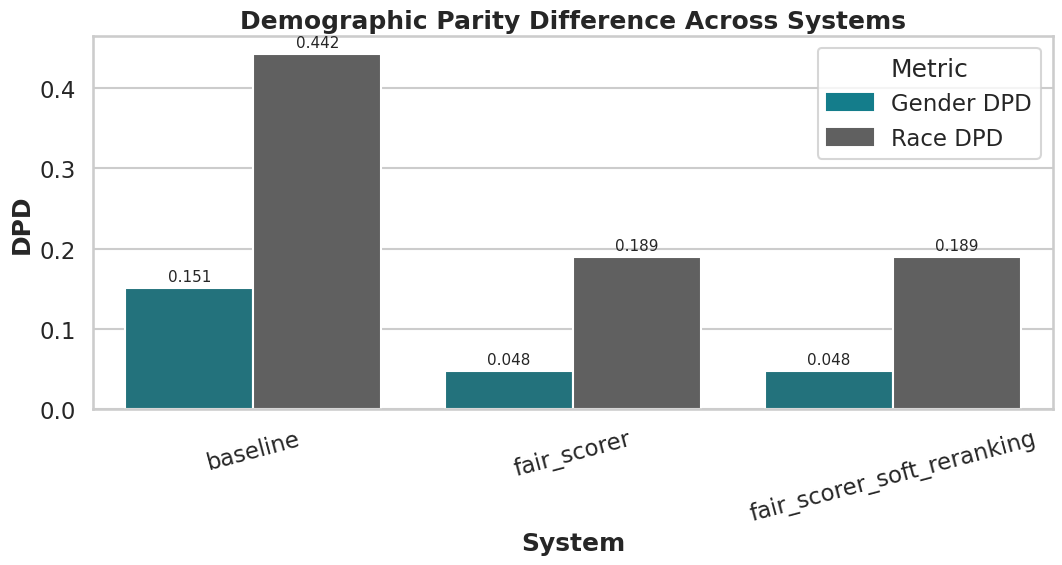

In [49]:
import matplotlib.patches as mpatches

plot_df = comparison_df.melt(
    id_vars="system",
    value_vars=["gender_dpd", "race_dpd"],
    var_name="metric",
    value_name="dpd"
)

plt.figure(figsize=(11, 6))
# Custom palette for Gender and Race
custom_palette = {"gender_dpd": "#147d8b", "race_dpd": "#606060"}
ax = sns.barplot(data=plot_df, x="system", y="dpd", hue="metric", palette=custom_palette)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=11)

plt.title("Demographic Parity Difference Across Systems")
plt.xlabel("System")
plt.ylabel("DPD")
plt.xticks(rotation=15)

# Properly define legend
gender_patch = mpatches.Patch(color='#147d8b', label='Gender DPD')
race_patch = mpatches.Patch(color='#606060', label='Race DPD')
plt.legend(handles=[gender_patch, race_patch], title="Metric")

plt.tight_layout()
plt.show()

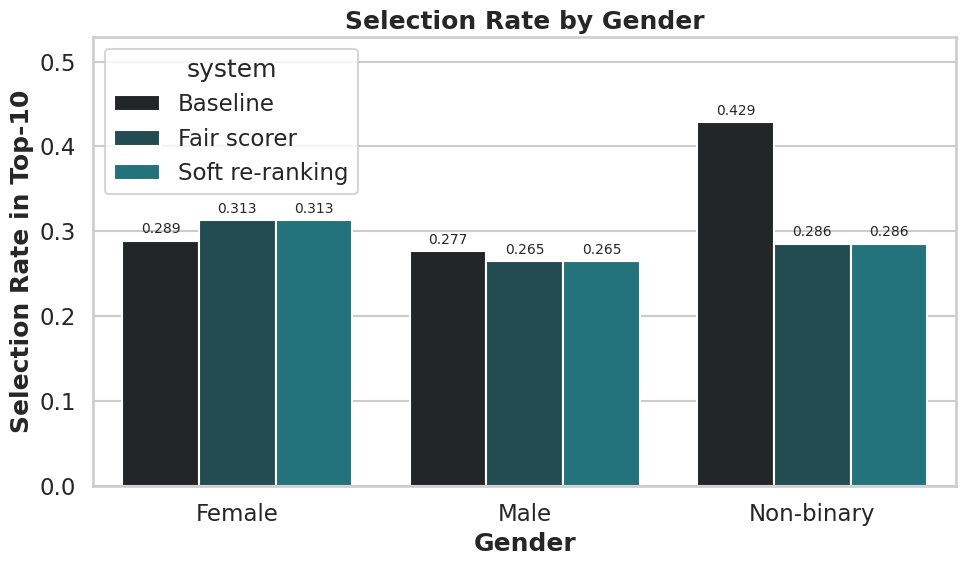

In [50]:
gender_baseline = (
    test_ranked.groupby("gender")["selected_top_k"]
    .mean()
    .reset_index(name="selection_rate")
)
gender_baseline["system"] = "Baseline"

gender_fair = (
    test_df.groupby("gender")["selected_top_k_fair"]
    .mean()
    .reset_index(name="selection_rate")
)
gender_fair["system"] = "Fair scorer"

gender_reranked = (
    reranked_df.groupby("gender")["selected_top_k_fair"]
    .mean()
    .reset_index(name="selection_rate")
)
gender_reranked["system"] = "Soft re-ranking"

gender_compare = pd.concat([gender_baseline, gender_fair, gender_reranked], ignore_index=True)

plt.figure(figsize=(10, 6))
# Applying requested color #147d8b for gender-based analysis
ax = sns.barplot(data=gender_compare, x="gender", y="selection_rate", hue="system", color="#147d8b")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=10)

plt.title("Selection Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Selection Rate in Top-10")
plt.ylim(0, max(gender_compare["selection_rate"]) + 0.1)
plt.tight_layout()
plt.show()

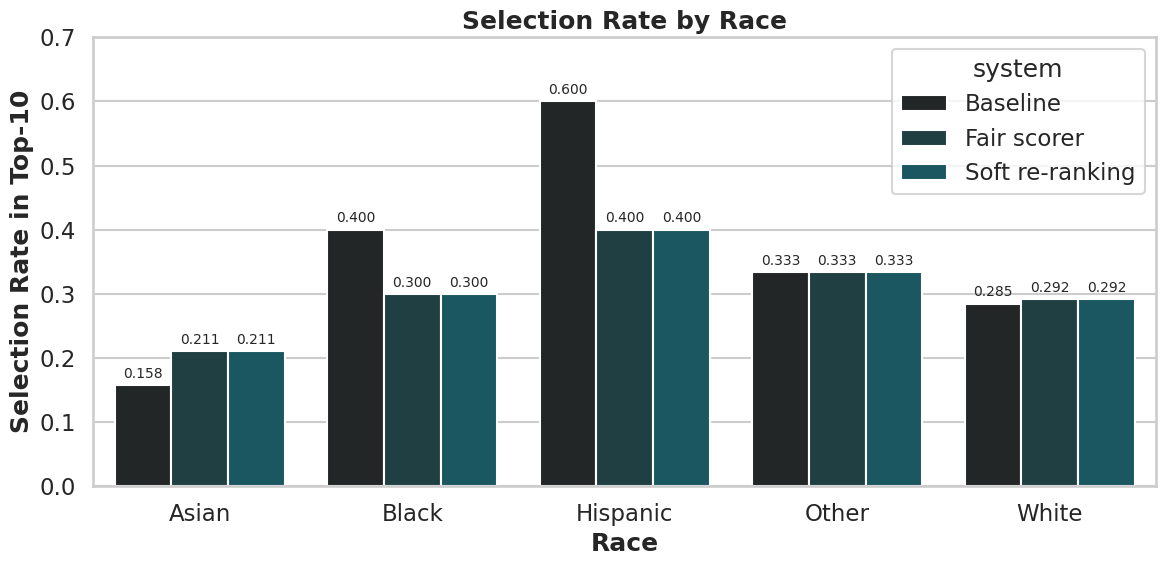

In [51]:
race_baseline = (
    test_ranked.groupby("race")["selected_top_k"]
    .mean()
    .reset_index(name="selection_rate")
)
race_baseline["system"] = "Baseline"

race_fair = (
    test_df.groupby("race")["selected_top_k_fair"]
    .mean()
    .reset_index(name="selection_rate")
)
race_fair["system"] = "Fair scorer"

race_reranked = (
    reranked_df.groupby("race")["selected_top_k_fair"]
    .mean()
    .reset_index(name="selection_rate")
)
race_reranked["system"] = "Soft re-ranking"

race_compare = pd.concat([race_baseline, race_fair, race_reranked], ignore_index=True)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=race_compare, x="race", y="selection_rate", hue="system", color="#0f606b")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=10)

plt.title("Selection Rate by Race")
plt.xlabel("Race")
plt.ylabel("Selection Rate in Top-10")
plt.ylim(0, max(race_compare["selection_rate"]) + 0.1)
plt.tight_layout()
plt.show()

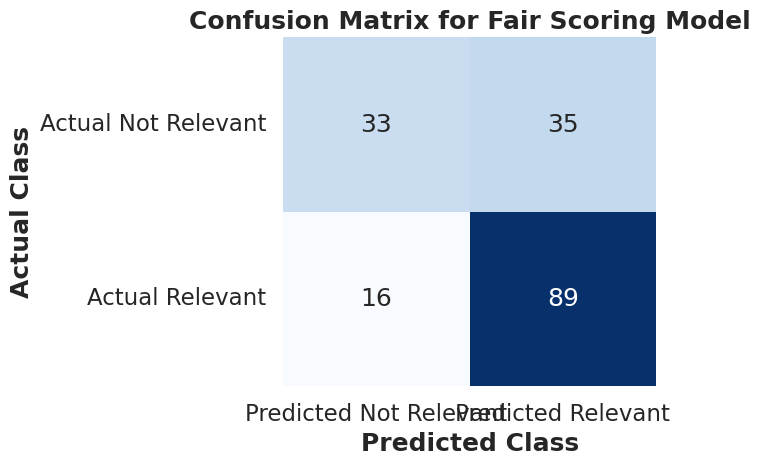

,Predicted Not Relevant,Predicted Relevant
Actual Not Relevant,33,35
Actual Relevant,16,89


In [52]:
cm = confusion_matrix(y_test, test_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Not Relevant", "Actual Relevant"],
    columns=["Predicted Not Relevant", "Predicted Relevant"]
)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix for Fair Scoring Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

display(cm_df)

Saving models

In [53]:
joblib.dump(scorer_model, os.path.join(MODEL_DIR, "fair_scorer_model.joblib"))
joblib.dump(gender_probe, os.path.join(MODEL_DIR, "gender_probe_model.joblib"))
joblib.dump(race_probe, os.path.join(MODEL_DIR, "race_probe_model.joblib"))

print("Models saved successfully.")

Models saved successfully.


In [54]:
test_ranked.to_csv(os.path.join(RESULTS_DIR, "baseline_rankings.csv"), index=False)
test_df.to_csv(os.path.join(RESULTS_DIR, "fair_scorer_results.csv"), index=False)
reranked_df.to_csv(os.path.join(RESULTS_DIR, "reranked_results.csv"), index=False)
comparison_df.to_csv(os.path.join(RESULTS_DIR, "fairness_comparison.csv"), index=False)

print("All results saved successfully.")

All results saved successfully.


In [55]:
utility_df = pd.DataFrame({
    "system": ["baseline_proxy", "fair_scorer"],
    "accuracy": [
        np.nan,
        accuracy_score(y_test, scorer_model.predict(X_test))
    ],
    "f1": [
        np.nan,
        f1_score(y_test, scorer_model.predict(X_test))
    ]
})

utility_df

,system,accuracy,f1
0,baseline_proxy,NaN,NaN
1,fair_scorer,0.705202,0.777293


In [56]:
print("Notebook completed successfully.")
print("Saved files in:")
print("Data:", DATA_DIR)
print("Models:", MODEL_DIR)
print("Results:", RESULTS_DIR)
print("Plots:", PLOTS_DIR)

Notebook completed successfully.
Saved files in:
Data: /content/drive/MyDrive/MSc IT/3rd sem/model/data
Models: /content/drive/MyDrive/MSc IT/3rd sem/model/models
Results: /content/drive/MyDrive/MSc IT/3rd sem/model/results
Plots: /content/drive/MyDrive/MSc IT/3rd sem/model/results/plots
